Coriolan Morel TP 1 k-means

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## Part 1


Part 1 - 1

In [2]:
X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

X.shape, y_true.shape

((300, 2), (300,))

part 1 - 2

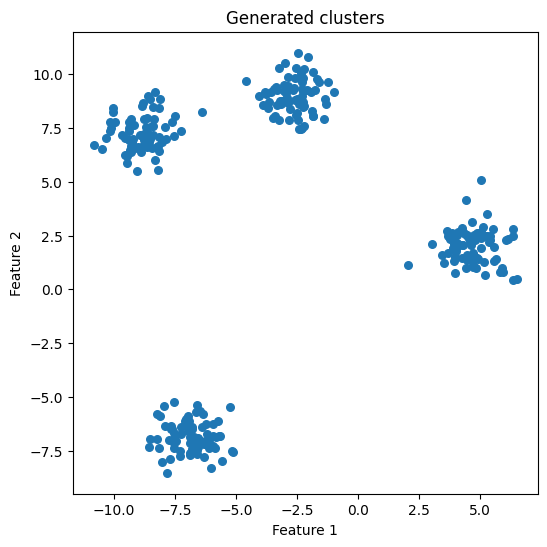

In [3]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=30)
plt.title("Generated clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

part 1 - 3 

We can clearly see 4 clusters.

They are well separated.

The shape is 300, 2. 

300 for the number of observations
2 for the number of variables

-----------

## Part 2

Part 2 - 1

In [4]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

y_pred = kmeans.fit_predict(X)


Part 2 - 2

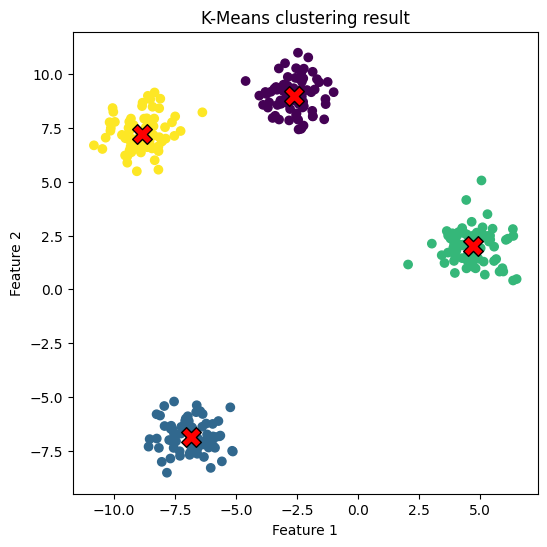

In [11]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(6,6))

plt.scatter(X[:,0], X[:,1], c=y_pred, cmap="viridis")

plt.scatter(
    centers[:,0],
    centers[:,1],
    c="red",
    marker="X",
    s=200,
    edgecolors="black"
)

plt.title("K-Means clustering result")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

Part 2 - 3


In [15]:
print("Inertia (WCSS):", kmeans.inertia_)        

print("Number of iterations:", kmeans.n_iter_)   

print("Centroid coordinates:\n", kmeans.cluster_centers_)  



Inertia (WCSS): 362.4724388277038
Number of iterations: 3
Centroid coordinates:
 [[-2.63715917  8.98563949]
 [-6.84180708 -6.84038791]
 [ 4.70253968  2.02807134]
 [-8.83330596  7.21790214]]


Inertia Wcss means the sum of squared distances from points to their cluster center (cluster compactness).

The number of iterations is literally the number of steps K-Means needed to converge

And the final print is the final (x, y) positions of the cluster centers

------

## Part 3

Part 3 - 1


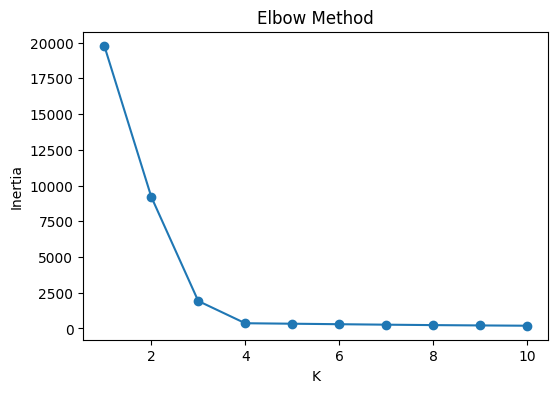

In [17]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

The elbow appears around K = 4

Yes, it matches the true number of clusters.

Part 3 - 2

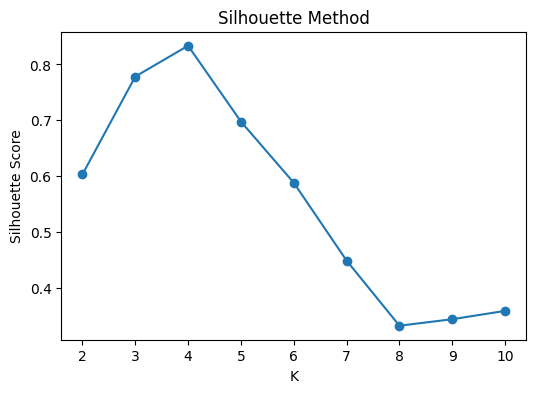

In [18]:
from sklearn.metrics import silhouette_score

scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.figure(figsize=(6,4))
plt.plot(K_range, scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

The highest silhouette score is at K = 4.


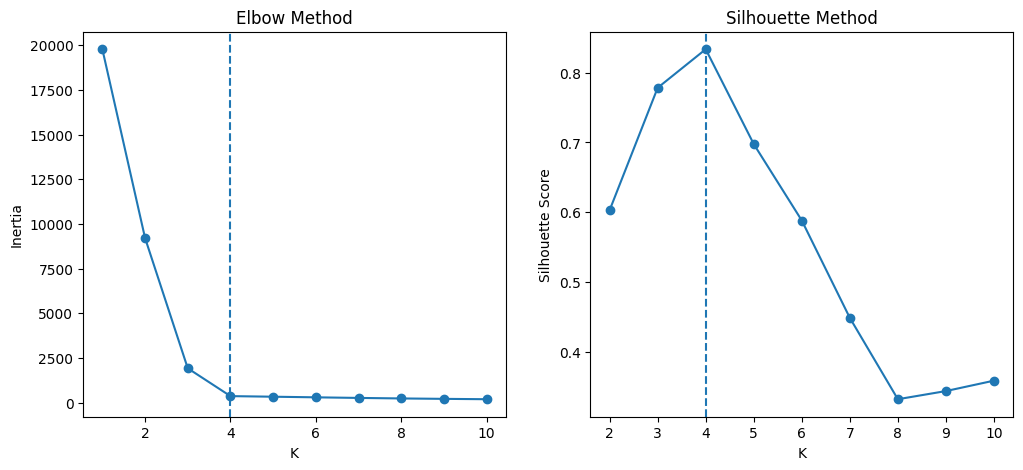

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

K_range_elbow = range(1,11)
ax1.plot(K_range_elbow, inertias, marker="o")
ax1.axvline(4, linestyle="--")
ax1.set_xlabel("K")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")

K_range_sil = range(2,11)
ax2.plot(K_range_sil, scores, marker="o")
ax2.axvline(4, linestyle="--")
ax2.set_xlabel("K")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Method")

plt.show()

Yes. Both methods agree on K = 4.

---


## Part 4

Part 4 - 1

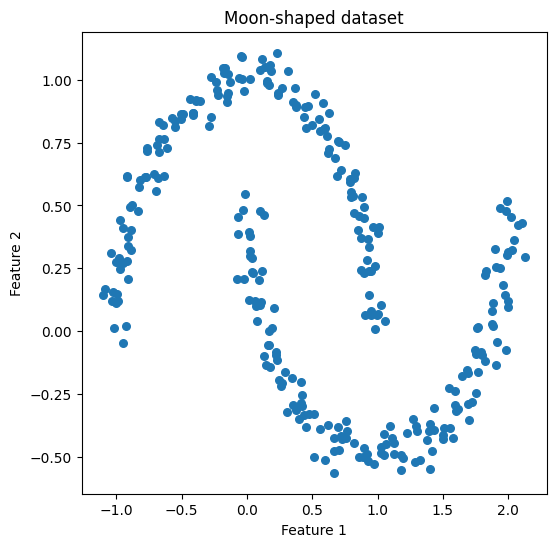

In [28]:
from sklearn.datasets import make_moons

X_moon, y_moon = make_moons(n_samples=300, noise=0.05, random_state=42)

plt.figure(figsize=(6,6))
plt.scatter(X_moon[:,0], X_moon[:,1], s=30)
plt.title("Moon-shaped dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Part 4 - 2

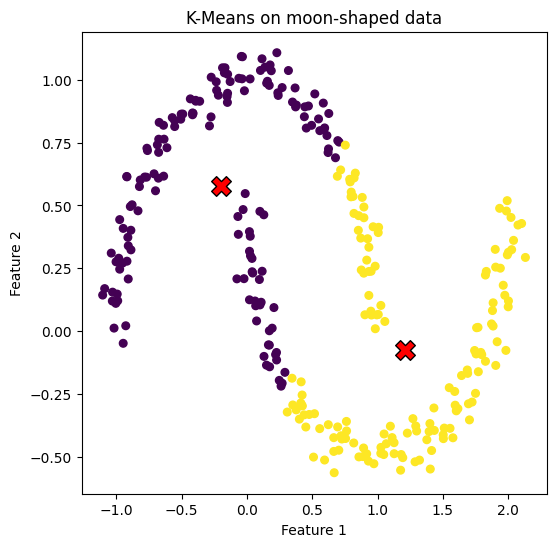

In [ ]:
kmeans_moon = KMeans(n_clusters=2, random_state=42, n_init=10)
y_moon_pred = kmeans_moon.fit_predict(X_moon)
centers_moon = kmeans_moon.cluster_centers_

plt.figure(figsize=(6,6))
plt.scatter(X_moon[:,0], X_moon[:,1], c=y_moon_pred, s=30, cmap="viridis")
plt.scatter(centers_moon[:,0], centers_moon[:,1], c="red", marker="X", s=200, edgecolors="black")
plt.title("K-Means on moon-shaped data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()



K-Means does not correctly separate the two moons.

It assumes clusters are roughly spherical and separated by distance to centroids.

Here, the moons are curved and non-convex, so K-Means splits the data incorrectly.

Part 4 - 3

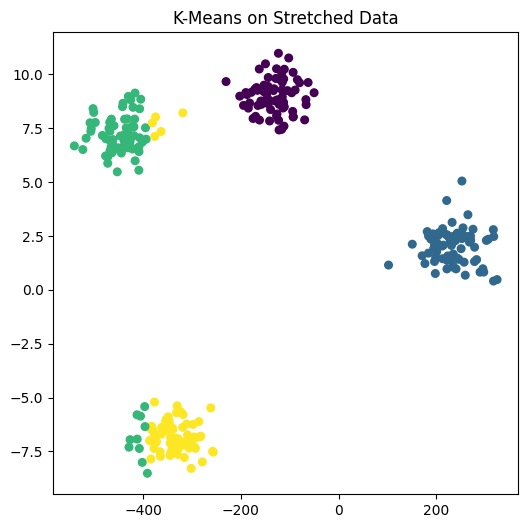

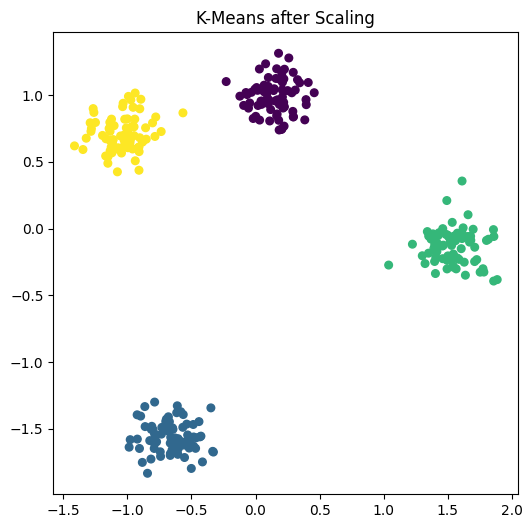

In [ ]:
from sklearn.preprocessing import StandardScaler

X_stretched = X.copy()
X_stretched[:,0] *= 50

kmeans_stretched = KMeans(n_clusters=4, random_state=42, n_init=10)
y_stretched = kmeans_stretched.fit_predict(X_stretched)

plt.figure(figsize=(6,6))
plt.scatter(X_stretched[:,0], X_stretched[:,1], c=y_stretched, cmap="viridis", s=30)
plt.title("K-Means on Stretched Data")
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_stretched)

kmeans_scaled = KMeans(n_clusters=4, random_state=42, n_init=10)
y_scaled = kmeans_scaled.fit_predict(X_scaled)

plt.figure(figsize=(6,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_scaled, cmap="viridis", s=30)
plt.title("K-Means after Scaling")
plt.show()


Without scaling, K-Means is biased by the stretched feature and clusters poorly.

After scaling, clusters are correctly recovered because both features have equal weight.